<a href="https://colab.research.google.com/github/wisabd/BBSim/blob/main/sampling_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Statistical Modelling Demonstration
*Juehang Qin*

[*Creative Commons Attribution 4.0 International License*](https://creativecommons.org/licenses/by/4.0/)

This notebook introduces how we can approach statistical modelling problems from a Bayesian perspective. The first half of the notebook focuses on generating some mock data; this is not necessarily interesting but serves as a demonstration that many of the "forward" or simulation problems we consider are statistical processes. The second half of this notebook implements a simple likelihood-based statistical model using numpyro and demonstrates how we can recover the true parameters, and demonstrate how we can check if our fit looks good.

## Setting up the problem

In particle physics experiments, we often encounter spectral data that consists of:

1. A signal of interest (often a peak at a specific energy)
2. Various background components
3. Detector effects that modify the observed spectrum

For this exercise, we'll create a simplified but realistic model of a detector looking for a signal peak against competing backgrounds. This scenario is common in searches for rare decays, dark matter, or new particles. This is modelled after what one might see in liquid xenon dark matter experiments.

Our model includes:

1. **Detector Response**:
   - A rolloff at low energies (threshold effect around 2 keV)
   - Zero response at zero energy (physical constraint)

2. **Background Components**:
   - A flat background (e.g., from ambient radioactivity)
   - A beta-decay spectrum that increases with energy (similar to Xe-136)

3. **Signal Component**:
   - A Gaussian peak at a specific energy

This setup mimics real-world experimental challenges in rare-event searches where the signal is a small peak on top of a complex background. The statistical task is to quantify the evidence for the signal and measure its parameters precisely.

In the first half of this notebook, we'll:
1. Define this model mathematically
2. Implement it computationally
3. Generate mock data with realistic statistical fluctuations

In the second half, we'll:
1. Construct a Bayesian model to analyze the data
2. Use MCMC (with NumPyro) to sample from the posterior
3. Evaluate how well we can recover the true parameters
4. Understand the correlations and uncertainties in our inference

This approach demonstrates the complete cycle of statistical analysis in physics: from theoretical model to simulated data to statistical inference.

In [ ]:
pip install numpyro matplotlib corner arviz graphviz

In [ ]:
from functools import partial
import arviz
import corner
import jax
import jax.numpy as jnp
from jax.scipy.stats import norm, poisson
from scipy.stats import chi2
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from tqdm import tqdm, trange

### Defining the "true" parameters

To generate some simulated or "toy" data, we need to define the true parameters for our detector and our signal. Here, we define some parameters.

 * `threshold` and `rolloff_width` define the low energy cutoff of the detector, implemented as a sigmoid multiplied by a function that rolls off to zero at zero energy to enforce a cutoff to zero efficiency at zero energy.
 * `bg_rate` defines the rate of the flat background in events/keV
 * `beta_slope` and `beta_offset` define a linear background component, such that $\mathtt{rate} = \mathtt{beta\_slope}\times E + \mathtt{beta\_offset}$ in units of events/keV.
 * `signal_mean` and `signal_sigma` define the energy and spread of the gaussian signal, whereas `signal_amplitude` defines the total number of signal events.
 * `min_energy` and `max_energy` define the minimum and maximum energy we consider for inference.



In [ ]:
# Parameters
threshold = 2.0           # Threshold rolloff center (in keV)
rolloff_width = 0.3       # Width of the rolloff transition
bg_rate = 30.0             # Flat background rate (events/keV)
beta_slope = 1          # Slope of increasing beta background (events/keV^2)
beta_offset = 0.0         # Offset of beta spectrum at 0 keV (should be 0)
signal_mean = 15.0         # Mean of Gaussian signal (in keV)
signal_sigma = 1        # Width of Gaussian signal (in keV)
signal_amplitude = 30.0    # Amplitude of the signal
min_energy = 0.0          # Minimum energy for analysis (in keV)
max_energy = 30.0          # Maximum energy for analysis (in keV)

# Exposure (default = 1)
exposure = 1.0            # Arbitrary exposure units

# Integration parameters
n_samples_integral = int(2 * (max_energy - min_energy))  # Default number of points for integration

# Create energy range from min_energy to max_energy keV
energy = jnp.linspace(min_energy, max_energy, 2000)

one_sigma_alpha = chi2.cdf(1, 1)

In [ ]:
# Model functions using JAX

def detector_response(energy, threshold, rolloff_width):
    """Detector response with threshold rolloff and zero at zero energy"""
    rolloff = 1 / (1 + jnp.exp(-(energy - threshold) / rolloff_width))
    low_energy_suppression = (1 - jnp.exp(-energy**2 / rolloff_width))
    return rolloff * low_energy_suppression

def flat_background_raw(energy, bg_rate):
    """Raw flat background component"""
    return jnp.ones_like(energy) * bg_rate

def beta_background_raw(energy, beta_slope, beta_offset=0.0):
    """Beta spectrum background component that increases with energy"""
    return beta_offset + beta_slope * energy

def signal_model(energy, mean, sigma, amplitude):
    """Gaussian signal model"""
    return amplitude * norm.pdf(energy, loc=mean, scale=sigma)

def total_model(energy, threshold, rolloff_width, bg_rate, beta_slope, beta_offset,
                signal_mean, signal_sigma, signal_amplitude):
    """Combined model with detector response applied to all components"""
    # Get detector response
    response = detector_response(energy, threshold, rolloff_width)

    # Calculate components with detector response
    flat_bg = flat_background_raw(energy, bg_rate) * response
    beta_bg = beta_background_raw(energy, beta_slope, beta_offset) * response
    sig = signal_model(energy, signal_mean, signal_sigma, signal_amplitude) * response

    return flat_bg + beta_bg + sig

@partial(jax.jit, static_argnames=['n_samples'])
def integrate_total_model(threshold, rolloff_width, bg_rate, beta_slope, beta_offset,
                         signal_mean, signal_sigma, signal_amplitude,
                         e_min=min_energy, e_max=max_energy, n_samples=None):
    """
    Integrate the total model between e_min and e_max using numerical integration.

    Parameters:
    -----------
    threshold, rolloff_width, bg_rate, beta_slope, beta_offset,
    signal_mean, signal_sigma, signal_amplitude : float
        Model parameters
    e_min, e_max : float
        Integration bounds
    n_samples : int, optional
        Number of points to use for integration.
        Default is 2*(e_max-e_min) if None.

    Returns:
    --------
    float : Integrated rate
    """
    # Set default number of samples if not provided
    if n_samples is None:
        n_samples = int(2 * (e_max - e_min))

    # Create energy grid for integration
    e_grid = jnp.linspace(e_min, e_max, n_samples)

    # Calculate model on grid
    rate = total_model(
        e_grid, threshold, rolloff_width, bg_rate, beta_slope, beta_offset,
        signal_mean, signal_sigma, signal_amplitude
    )

    # Integrate using trapezoidal rule
    return jnp.trapezoid(rate, e_grid)

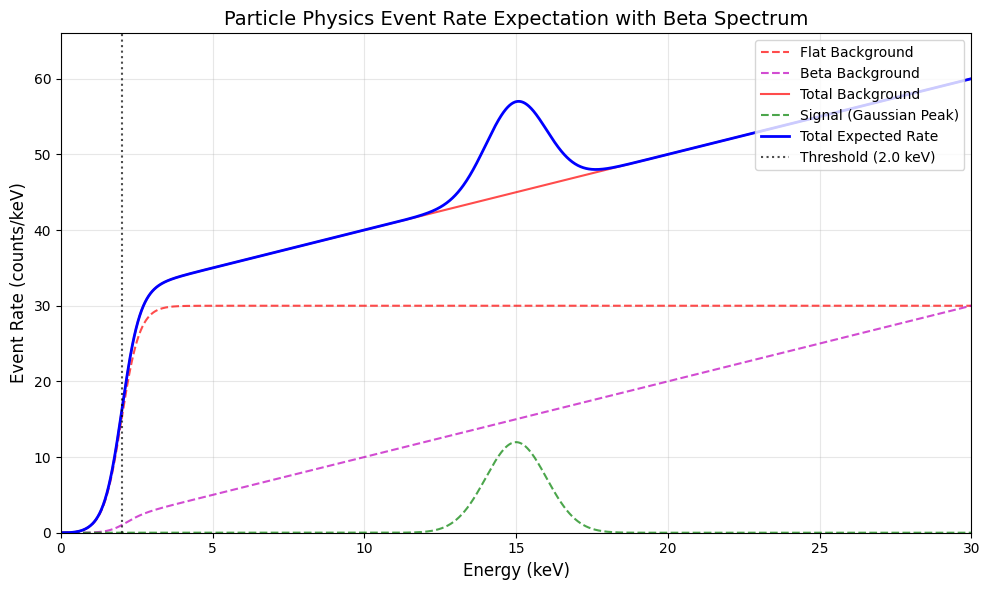

In [ ]:
# Calculate detector response
response = detector_response(energy, threshold, rolloff_width)

# Calculate components with detector response applied
flat_background = flat_background_raw(energy, bg_rate) * response
beta_background = beta_background_raw(energy, beta_slope, beta_offset) * response
total_background = flat_background + beta_background
signal = signal_model(energy, signal_mean, signal_sigma, signal_amplitude) * response
total_rate = total_background + signal

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the detector response and model components
ax.plot(energy, flat_background, 'r--', label='Flat Background', alpha=0.7)
ax.plot(energy, beta_background, 'm--', label='Beta Background', alpha=0.7)
ax.plot(energy, total_background, 'r-', label='Total Background', alpha=0.7)
ax.plot(energy, signal, 'g--', label='Signal (Gaussian Peak)', alpha=0.7)
ax.plot(energy, total_rate, 'b-', label='Total Expected Rate', linewidth=2)

# Add vertical line at threshold
ax.axvline(x=threshold, color='k', linestyle=':', alpha=0.7,
           label=f'Threshold ({threshold} keV)')

# Set labels and title
ax.set_xlabel('Energy (keV)', fontsize=12)
ax.set_ylabel('Event Rate (counts/keV)', fontsize=12)
ax.set_title('Particle Physics Event Rate Expectation with Beta Spectrum', fontsize=14)

# Add legend and grid
ax.legend(loc='upper right', frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)

# Set axis limits
ax.set_xlim(0, max_energy)
ax.set_ylim(0, total_rate.max() * 1.1)

# Show plot with tight layout
plt.tight_layout()
plt.show()



### Generating Simulated Data

There are a few approaches to generating data with a known spectrum. Here, I opt to use a rather general approach that can sample from any spectrum, even ones that are not analytic or even continuous. Step one is to sample from the poisson distribution to determine the total event count, and step 2 is to sample from a uniform distribution within the interval [0,1], and then transform it into our desired sample using an inverse CDF transformation.

#### Poisson Process for Event Counts

Particle detection follows a Poisson process:

$$P(n|\mu) = \frac{e^{-\mu} \mu^n}{n!}$$

The expected count ($\mu$) is calculated from the integrated rate and exposure. The actual number of events ($N$) is sampled from this distribution.

#### Inverse CDF Method for Energy Distribution

For each event, energy values are sampled as such:

1. Normalize the rate spectrum to create a PDF, $p(E)$
2. Compute the CDF, $F(E)$: $F(E) = \int_{0}^{E} p(E') dE'$
3. Generate uniform random numbers $u \sim \text{Uniform}(0,1)$
4. Find energy values where $F(E) = u$. In practice, we approximate $F(E)$ by computing the values of $F(E)$ at a set number of points and linearly interpolate.

This combination of Poisson sampling for counts and inverse CDF sampling for energies creates a dataset with the appropriate statistical properties for testing our inference methods.

In [ ]:
pdf = total_rate / jnp.trapezoid(total_rate, energy)  # Normalize to create PDF
cdf = jnp.cumsum(pdf) / jnp.sum(pdf)  # Compute CDF

# Calculate the total integrated rate
total_integrated_rate = integrate_total_model(
    threshold, rolloff_width, bg_rate, beta_slope, beta_offset,
    signal_mean, signal_sigma, signal_amplitude,
    n_samples=n_samples_integral
)

In [ ]:
@jax.jit
def inverse_cdf_sample_linear(u, energy, cdf):
    # Find the indices where cdf crosses u
    idx = jnp.searchsorted(cdf, u)

    # Ensure we have a valid previous index
    idx = jnp.clip(idx, 1, len(cdf) - 1)

    # Get the bracketing CDF values and energies
    cdf_low = cdf[idx - 1]
    cdf_high = cdf[idx]
    e_low = energy[idx - 1]
    e_high = energy[idx]

    # Linear interpolation
    denominator = jnp.maximum(cdf_high - cdf_low, 1e-10)  # Avoid division by zero
    fraction = (u - cdf_low) / denominator
    e_interp = e_low + (e_high - e_low) * fraction

    # Handle edge cases
    e_interp = jnp.where(u <= cdf[0], energy[0], e_interp)
    e_interp = jnp.where(u >= cdf[-1], energy[-1], e_interp)

    return e_interp

# Generate samples using inverse CDF method
def generate_samples(key, n_samples, energy, cdf):
    """Generate energy samples using inverse CDF method"""
    # Generate uniform random numbers
    u = jax.random.uniform(key, (n_samples,))
    # Apply inverse CDF transform
    return jax.vmap(inverse_cdf_sample_linear, in_axes=(0, None, None))(u, energy, cdf)

# Function to calculate asymmetric Poisson confidence intervals using chi-square distribution
def poisson_conf_interval(counts, conf=one_sigma_alpha):
    """
    Calculate asymmetric Poisson confidence intervals using the chi-square method.

    Parameters:
    -----------
    counts : array
        Observed counts
    conf : float
        Confidence level (default: 1-sigma for normal distribution, ~0.68)

    Returns:
    --------
    (lower, upper) : tuple of arrays
        Lower and upper confidence bounds
    """
    # Handle zero counts separately
    n = jnp.asarray(counts)

    # For zero counts, use conservative approximation
    lower = jnp.where(n > 0, chi2.ppf((conf)/2, 2*n) / 2, 0)
    upper = chi2.ppf(1-(conf)/2, 2*n + 2) / 2

    # Return lower and upper bounds
    return (n - lower, upper - n)

In [ ]:
# Calculate the expected number of events
expected_events = total_integrated_rate * exposure

# Sample the total number of events from Poisson distribution
key, key1, key2 = jax.random.split(jax.random.PRNGKey(42), 3)
n_events = jax.random.poisson(key1, expected_events)

# Generate energy samples using inverse CDF
simulated_data_samples = generate_samples(key2, n_events, energy, cdf)

In [ ]:
# Create histogram of sampled events for visualization
hist_bins = jnp.linspace(min_energy, max_energy, int(round(max_energy-min_energy))+1)
hist_values, _ = jnp.histogram(simulated_data_samples, bins=hist_bins)
hist_centers = 0.5 * (hist_bins[1:] + hist_bins[:-1])
bin_widths = jnp.diff(hist_bins)

# Convert histogram to rate for comparison with model
hist_rate = hist_values / (bin_widths * exposure)

# Calculate asymmetric Poisson errors for histogram values
hist_errors_low, hist_errors_high = poisson_conf_interval(hist_values)
# Convert count errors to rate errors
hist_errors_low = hist_errors_low / (bin_widths * exposure)
hist_errors_high = hist_errors_high / (bin_widths * exposure)
# Create asymmetric error bars for plotting
hist_yerr = [hist_errors_low, hist_errors_high]

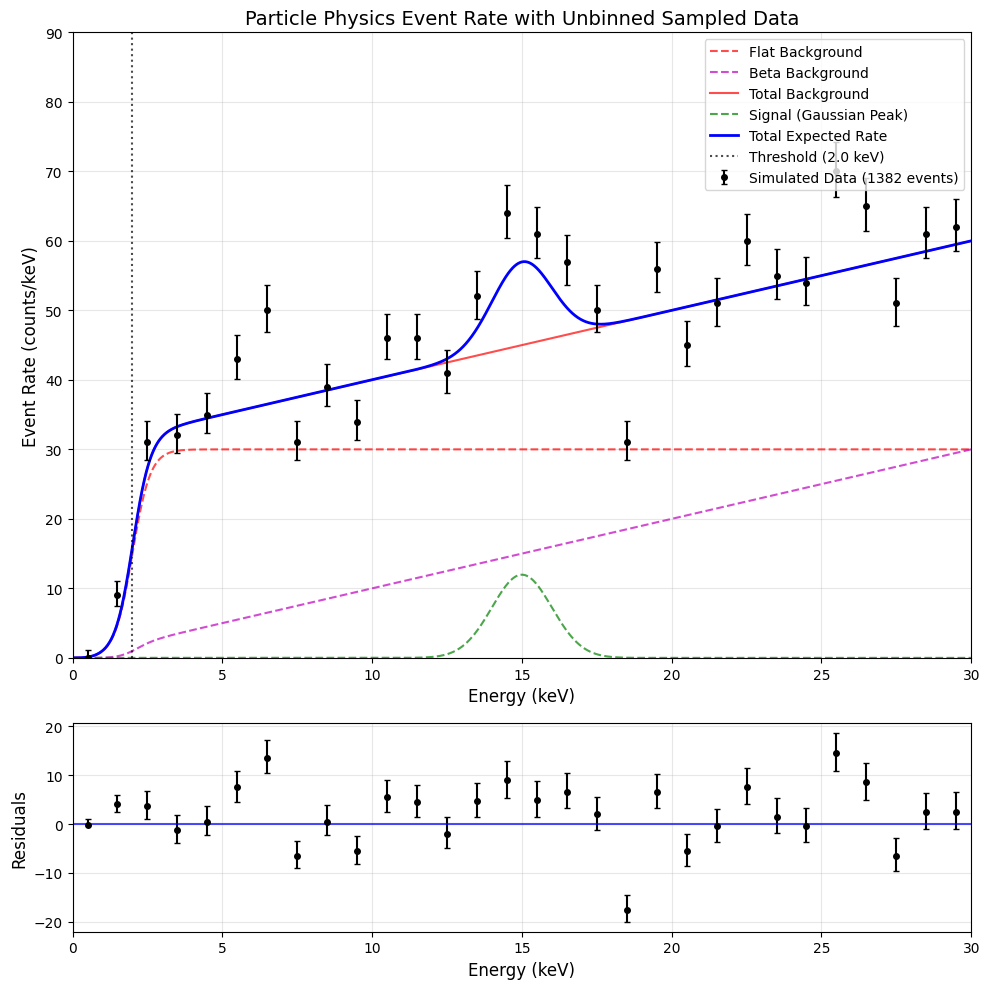

In [ ]:
# Create plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [3, 1]})

# Plot model components on top panel
ax1.plot(energy, flat_background, 'r--', label='Flat Background', alpha=0.7)
ax1.plot(energy, beta_background, 'm--', label='Beta Background', alpha=0.7)
ax1.plot(energy, total_background, 'r-', label='Total Background', alpha=0.7)
ax1.plot(energy, signal, 'g--', label='Signal (Gaussian Peak)', alpha=0.7)
ax1.plot(energy, total_rate, 'b-', label='Total Expected Rate', linewidth=2)

# Plot the sampled data with asymmetric error bars
ax1.errorbar(hist_centers, hist_rate, yerr=hist_yerr, fmt='ko',
             label=f'Simulated Data ({n_events} events)', markersize=4, capsize=2)

# Add vertical line at threshold
ax1.axvline(x=threshold, color='k', linestyle=':', alpha=0.7,
           label=f'Threshold ({threshold} keV)')

# Set labels and title for top panel
ax1.set_xlabel('Energy (keV)', fontsize=12)
ax1.set_ylabel('Event Rate (counts/keV)', fontsize=12)
ax1.set_title('Particle Physics Event Rate with Unbinned Sampled Data', fontsize=14)
ax1.legend(loc='upper right', frameon=True, fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(min_energy, max_energy)
ax1.set_ylim(0, total_rate.max() * 1.5)

# Plot residuals on bottom panel with asymmetric errors
model_at_bins = jnp.interp(hist_centers, energy, total_rate)
residuals = hist_rate - model_at_bins

# Plot residuals with asymmetric error bars
ax2.errorbar(hist_centers, residuals, yerr=hist_yerr, fmt='ko', markersize=4, capsize=2)
ax2.axhline(y=0, color='b', linestyle='-', alpha=0.7)

# Set labels for bottom panel
ax2.set_xlabel('Energy (keV)', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(min_energy, max_energy)

plt.tight_layout()
plt.show()

## Statistical Model

In this section, we implement a Bayesian statistical model to analyze our simulated data and recover the underlying parameters of interest.

### Likelihood Function

The likelihood function quantifies how probable our observed data is, given a specific set of model parameters. For our particle physics example, the likelihood has two key components:

1. **Energy Distribution Likelihood**: This measures how well our model explains the distribution of observed energies. Since we're using unbinned data (individual event energies rather than histograms), we use a continuous probability density function (PDF).

2. **Total Event Count Likelihood**: This measures how well our model explains the total number of observed events, which follows a Poisson distribution.

#### Unbinned Energy Likelihood

For each observed energy value, the likelihood is proportional to the value of our model's PDF at that energy. For all events combined:

$$\mathcal{L}_{\text{energy}}(\theta) = \prod_{i=1}^{N} \frac{f(E_i | \theta)}{\int_{E_{\text{min}}}^{E_{\text{max}}} f(E | \theta) dE}$$

Where:
- $\theta$ represents our set of model parameters
- $f(E|\theta)$ is our model's rate function (events/keV)
- $E_i$ are the observed energy values
- $N$ is the number of observed events
- The denominator normalizes the rate function to create a proper PDF

In log form, which is numerically more stable:

$$\log \mathcal{L}_{\text{energy}}(\theta) = \sum_{i=1}^{N} \log\left(\frac{f(E_i | \theta)}{\int_{E_{\text{min}}}^{E_{\text{max}}} f(E | \theta) dE}\right)$$

#### Poisson Event Count Likelihood

The total number of observed events follows a Poisson distribution with mean equal to the integrated model rate times the exposure:

$$\mathcal{L}_{\text{count}}(\theta) = \frac{(\mu(\theta))^N e^{-\mu(\theta)}}{N!}$$

Where:
- $\mu(\theta) = \text{exposure} \times \int_{E_{\text{min}}}^{E_{\text{max}}} f(E|\theta) dE$

In log form:

$$\log \mathcal{L}_{\text{count}}(\theta) = N \log(\mu(\theta)) - \mu(\theta) - \log(N!)$$

#### Total Likelihood

The complete log-likelihood combines both components:

$$\log \mathcal{L}(\theta) = \log \mathcal{L}_{\text{energy}}(\theta) + \log \mathcal{L}_{\text{count}}(\theta)$$

In our NumPyro implementation, we explicitly construct this likelihood using the `numpyro.factor` and `numpyro.sample` primitives.

### Prior Distributions

Prior distributions encode our knowledge or assumptions about the parameters before observing the data. For this analysis, we've chosen the following priors:

1. **Detector Parameters**:
   - `threshold`: LogNormal(0.69, 0.1) - A narrow range around the truth is used because typically we would measure this for a detector.
   - `rolloff_width`: LogNormal(-1.20, 0.1) - A narrow range around the truth is used because typically we would measure this for a detector.

2. **Background Parameters**:
   - `bg_rate`: Uniform(10, 100) - For the flat background rate
   - `beta_slope`: Uniform(0.01, 5.0) - For the slope of the beta spectrum
   - `beta_offset`: Fixed at 0.0 - Physical constraint as beta spectrum should start at zero

3. **Signal Parameters**:
   - `signal_mean`: Uniform(4, max_energy-2) - The energy range where we expect our signal peak, chosen to avoid edge effects.
   - `signal_sigma`: LogNormal(0.0, 0.1) - A log-normal is used here with a narrow width because typically we would have a good understanding of the width of a mono-energetic signal via calibration and detector modelling.
   - `signal_amplitude`: Uniform(0.1, 200.0) - Range of possible signal strengths

These priors are deliberately chosen to be weakly informative with the exception of `signal_sigma`. They specify reasonable ranges based on physics knowledge but don't strongly bias the posterior toward specific values within those ranges. The log-normal prior for `signal_sigma` encodes our belief that the resolution is positive and more likely to be small than large.

### Model Implementation in NumPyro

Our model is implemented using NumPyro, a probabilistic programming library that supports Bayesian inference with MCMC. The model function:

1. Samples parameters from prior distributions
2. Constructs the rate model based on these parameters
3. Calculates the expected number of events
4. Computes the log-likelihood for the observed energies
5. Computes the log-likelihood for the total number of events

The `NUTS` (No-U-Turn Sampler) algorithm is then used to efficiently sample from the posterior distribution, providing estimates of the parameters and their uncertainties. This is a variation of MCMC, which we discussed during the lecture.

In [ ]:
jnp.log(0.3)

Array(-1.2039728, dtype=float32, weak_type=True)

In [ ]:
def unbinned_model(energies, n_samples_integral=int(2 * (max_energy - min_energy))):
    # Priors
    threshold = numpyro.sample('threshold', dist.LogNormal(0.69, 0.1))
    rolloff_width = numpyro.sample('rolloff_width', dist.LogNormal(-1.20, 0.1))
    bg_rate = numpyro.sample('bg_rate', dist.Uniform(10, 100))
    beta_slope = numpyro.sample('beta_slope', dist.Uniform(0.01, 5.0))
    signal_mean = numpyro.sample('signal_mean', dist.Uniform(4, max_energy-2))
    signal_sigma = numpyro.sample('signal_sigma', dist.LogNormal(0.0, 0.1))
    signal_amplitude = numpyro.sample('signal_amplitude', dist.Uniform(0.1, 200.0))

    # Fixed parameter
    beta_offset = 0.0  # Fixed at zero

    # Create a fine energy grid for the model
    fine_energy = jnp.linspace(min_energy, max_energy, n_samples_integral)

    # Calculate the rate model
    rate = total_model(
        fine_energy,
        threshold,
        rolloff_width,
        bg_rate,
        beta_slope,
        beta_offset,
        signal_mean,
        signal_sigma,
        signal_amplitude
    )

    # Calculate the total rate using numerical integration
    total_integrated_rate = integrate_total_model(
        threshold, rolloff_width, bg_rate, beta_slope, beta_offset,
        signal_mean, signal_sigma, signal_amplitude,
        n_samples=n_samples_integral
    )

    # Expected number of events (Poisson rate parameter)
    expected_events = total_integrated_rate * exposure

    # Normalize to create PDF
    pdf = rate / total_integrated_rate

    # Calculate log likelihood for observed energies
    def energy_logpdf(energies):
        # Interpolate PDF at observed energies
        pdf_at_points = jnp.interp(energies, fine_energy, pdf)
        # Sum log probabilities (unbinned likelihood)
        return jnp.sum(jnp.log(pdf_at_points))

    # Add observed events using explicit likelihood
    numpyro.factor("energy_likelihood", energy_logpdf(energies))

    # Add Poisson likelihood for total number of events
    numpyro.sample("n_events", dist.Poisson(expected_events), obs=len(energies))

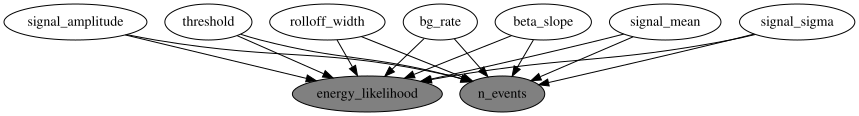

In [ ]:
numpyro.render_model(unbinned_model, model_args=(simulated_data_samples,))

### Posterior Analysis

After sampling from the posterior, we'll:

1. Examine trace plots to confirm convergence
2. Visualize the joint posterior distributions using corner plots
3. Generate posterior predictive checks to assess model fit
4. Calculate parameter estimates with credible intervals

This Bayesian approach provides a complete statistical model that naturally handles parameter uncertainties and correlations, crucial for accurately characterizing the signal properties in the presence of background and detector effects.

The first thing we do is to ensure there are no divergences. Divergences are a major red flag in MCMC, and suggest that the step size is too big to properly sample the posterior! In this case, the problem is purposely set up to have divergences; we resolve this by decreasing the `target_accept_prob` parameter. Increasing the value of this parameter effectively reduces the step size, making sampling more computationally expensive but improving the accuracy.

$\hat{R}$ is another useful diagnostic. This parameter represents the ratio of variances between MCMC chains to that within a single MCMC chain. If each MCMC chain successfully explores the entire posterior, then we should get $\hat{R}\approx1$. Taking a quick look at the trace plot also helps us ensure that the different chains are behaving similarly, and that no chain is getting stuck.

It is worth noting that tuning the NUTS MCMC sampler is a bit of a dark art, and can sometimes be helped by reparameterisation.

In [ ]:
key, nuts_key = jax.random.split(key, 2)
nuts_kernel = NUTS(unbinned_model, target_accept_prob=0.4)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=1000, num_chains=3, chain_method='vectorized')
mcmc.run(nuts_key, simulated_data_samples)  # samples is our array of event energies
mcmc.print_summary()

sample: 100%|██████████| 2000/2000 [01:20<00:00, 24.89it/s]


                        mean       std    median      5.0%     95.0%     n_eff     r_hat
        beta_slope      0.97      0.16      0.97      0.73      1.25    206.86      1.01
           bg_rate     32.26      2.73     32.14     27.89     36.66    196.17      1.01
     rolloff_width      0.30      0.03      0.30      0.25      0.34    253.87      1.02
  signal_amplitude     45.10     16.31     45.12     21.25     74.79    283.61      1.00
       signal_mean     15.16      1.41     15.07     14.41     15.98    294.93      1.02
      signal_sigma      0.99      0.09      0.99      0.86      1.15    237.09      1.01
         threshold      1.92      0.11      1.93      1.74      2.09    216.13      1.01

Number of divergences: 360


In [ ]:
nuts_kernel = NUTS(unbinned_model, target_accept_prob=0.8)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=1000, num_chains=3, chain_method='vectorized')
mcmc.run(nuts_key, simulated_data_samples)  # samples is our array of event energies
mcmc.print_summary()

sample: 100%|██████████| 2000/2000 [01:47<00:00, 18.68it/s]



                        mean       std    median      5.0%     95.0%     n_eff     r_hat
        beta_slope      0.98      0.16      0.98      0.72      1.26   1782.50      1.00
           bg_rate     32.20      2.78     32.15     27.89     36.97    908.85      1.01
     rolloff_width      0.30      0.03      0.30      0.25      0.35   2589.15      1.00
  signal_amplitude     42.45     17.96     43.04     10.50     71.38    126.06      1.02
       signal_mean     15.43      2.55     15.09     13.96     16.25     23.34      1.17
      signal_sigma      1.00      0.10      0.99      0.84      1.16   2569.29      1.00
         threshold      1.91      0.11      1.91      1.72      2.09   2819.77      1.00

Number of divergences: 0


In [ ]:
posterior = arviz.from_numpyro(mcmc)

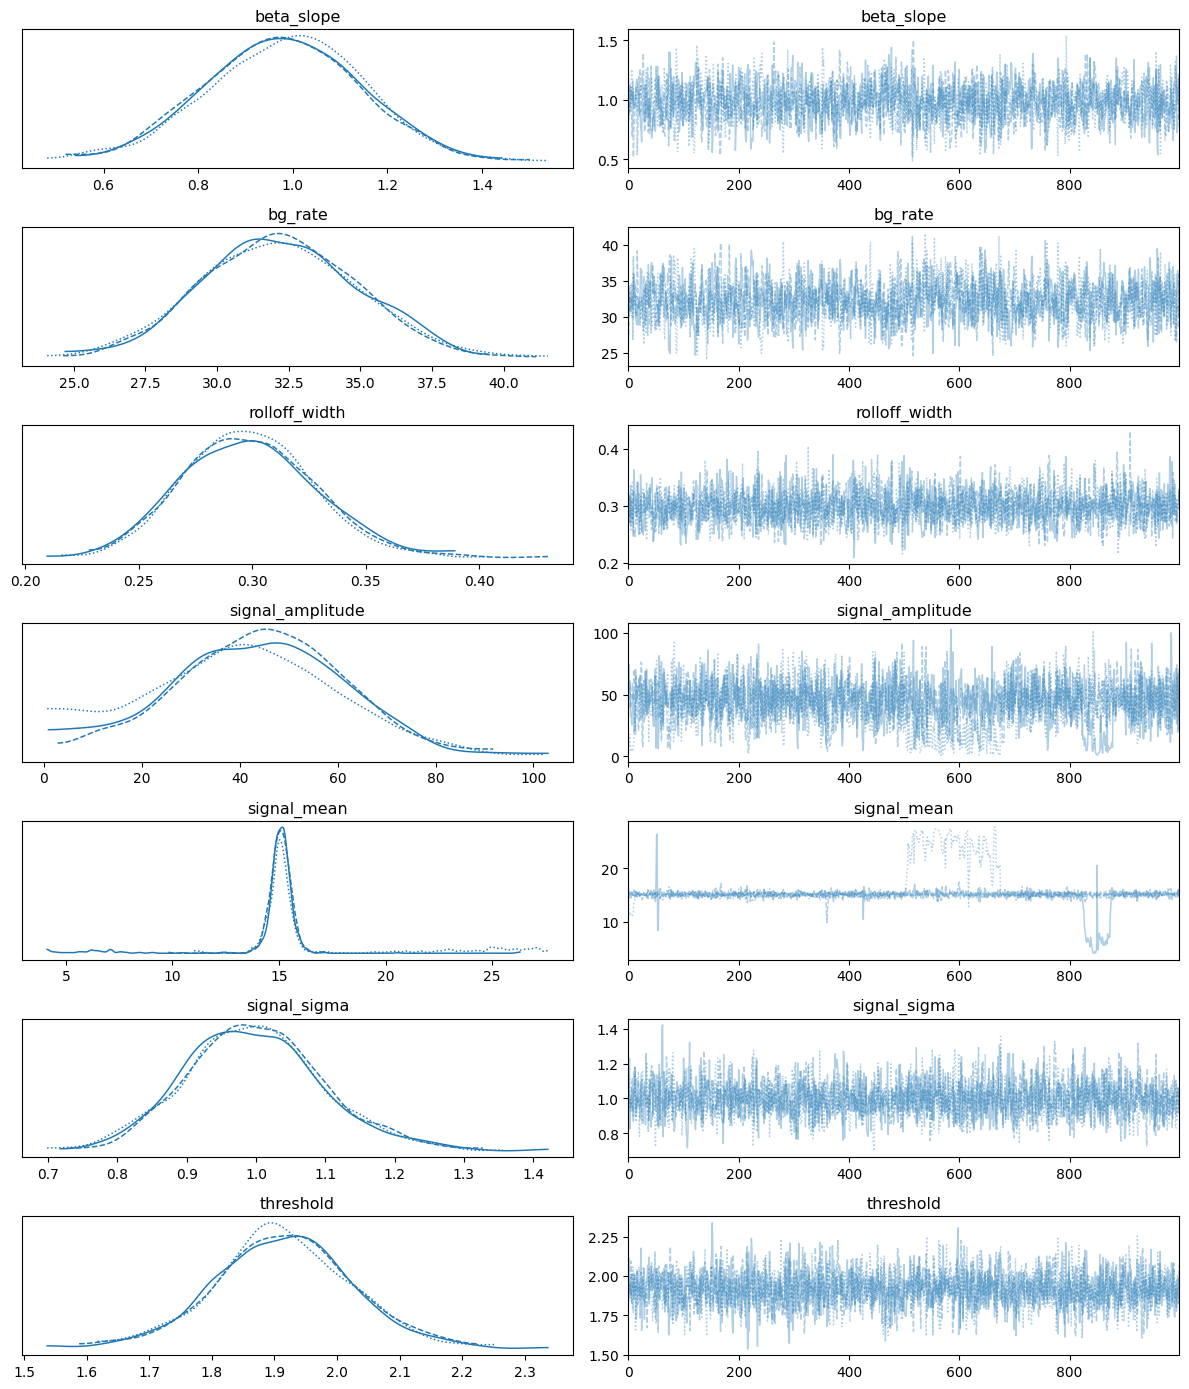

In [ ]:
arviz.plot_trace(posterior)
plt.tight_layout()
plt.show()

### Best fit parameters

In the following corner plot, we can see the posterior distribution. Because this data is simulated, we know the truth parameters, and we can see that the truth parameters are indeed covered by the posterior distribution.

We can also look at the best fit spectrum, and the epistemic and aleatoric uncertainties. In this case, we can see that the posterior from the Bayesian model does match our data reasonably well.

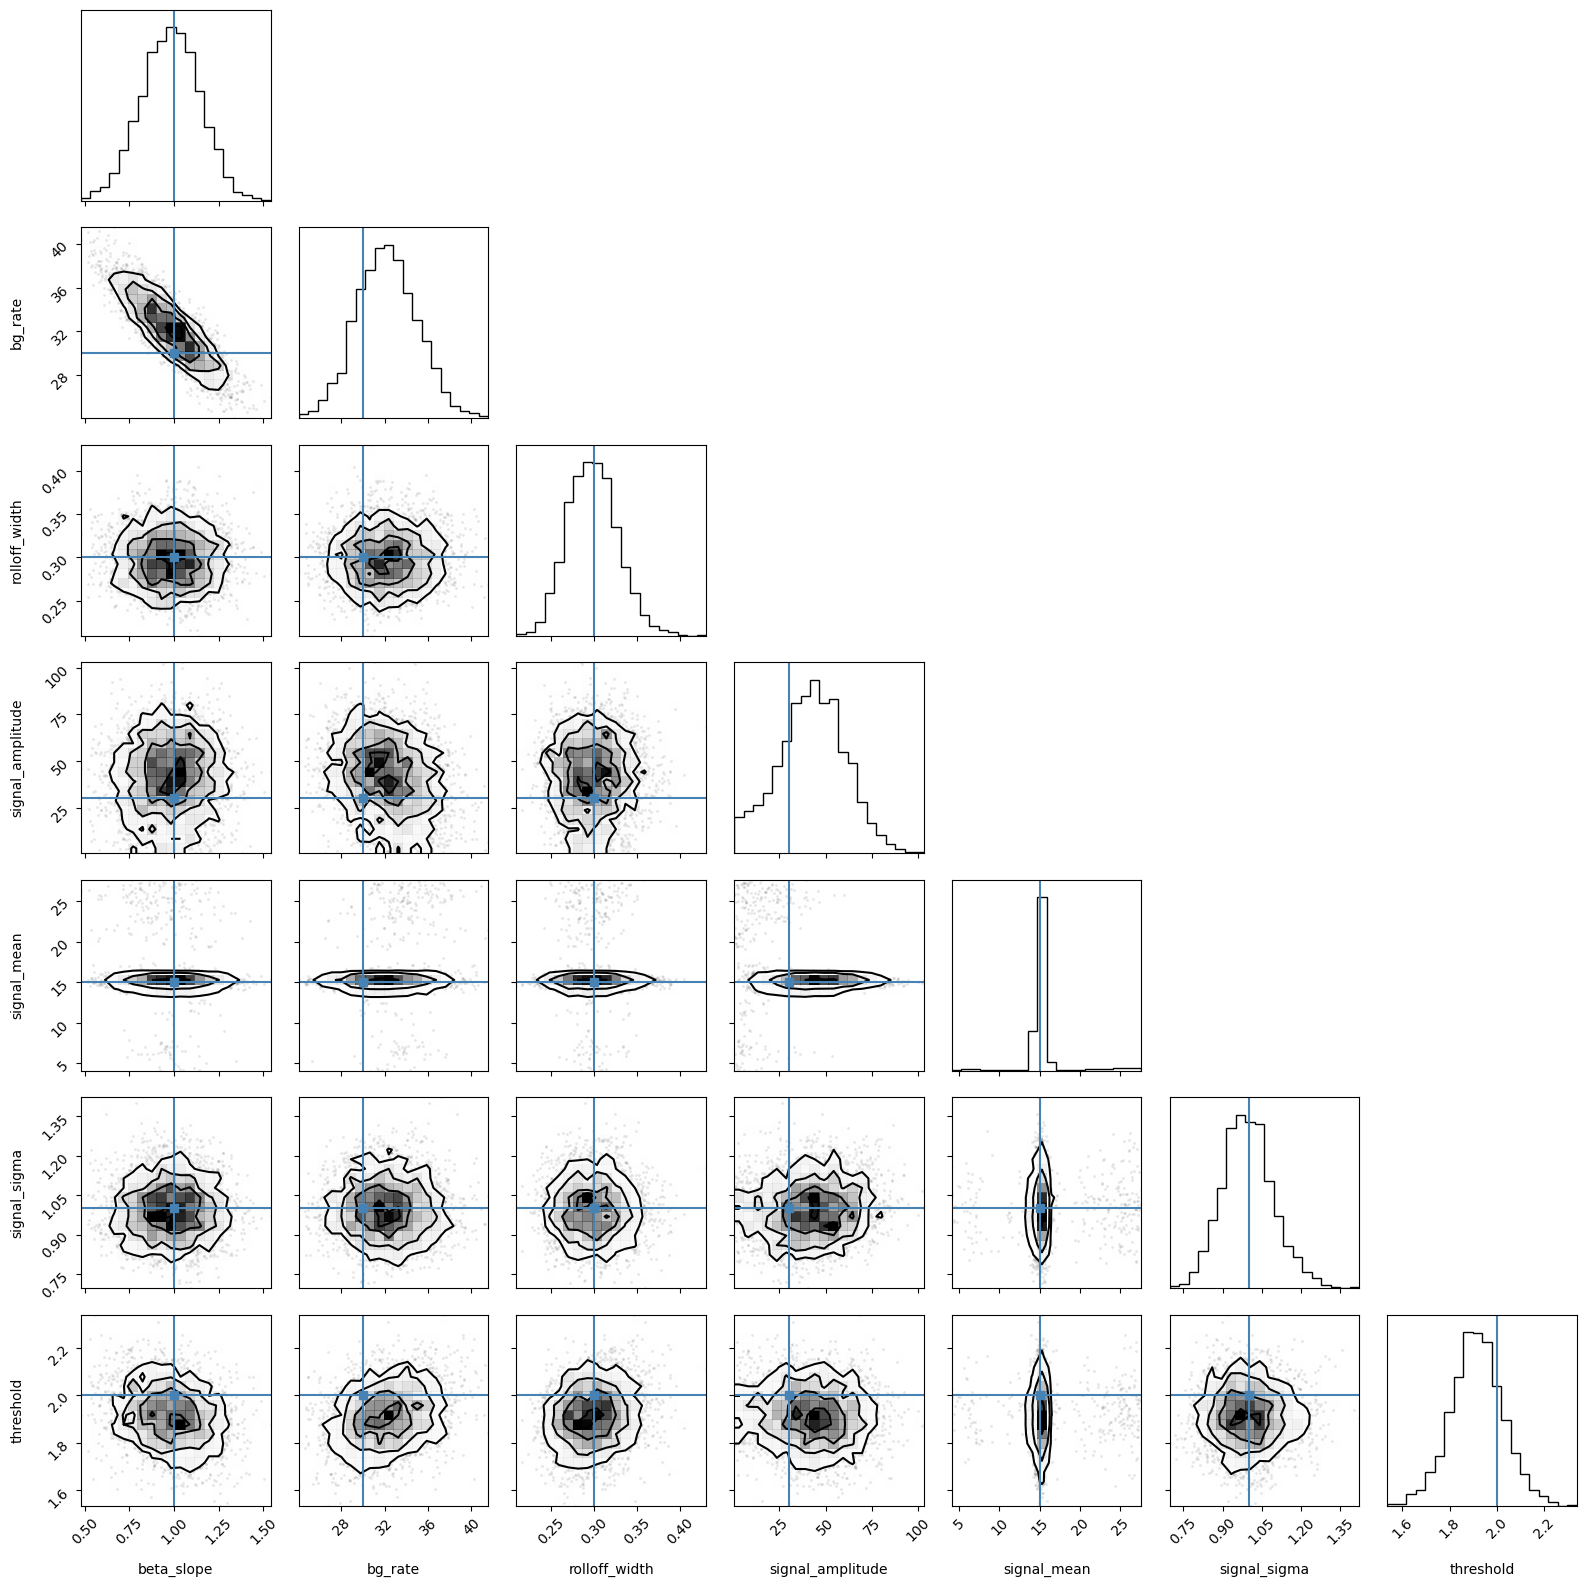

In [ ]:
corner.corner(posterior, truths={
    'threshold': threshold,
    'rolloff_width': rolloff_width,
    'bg_rate': bg_rate,
    'beta_slope': beta_slope,
    'signal_mean': signal_mean,
    'signal_sigma': signal_sigma,
    'signal_amplitude': signal_amplitude
})
plt.tight_layout()
plt.show()

In [ ]:
# Define a function to generate the model for a set of parameters
@jax.jit
def get_model_rate(theta, energy_grid):
    threshold = theta['threshold']
    rolloff_width = theta['rolloff_width']
    bg_rate = theta['bg_rate']
    beta_slope = theta['beta_slope']
    beta_offset = 0.0  # Fixed parameter
    signal_mean = theta['signal_mean']
    signal_sigma = theta['signal_sigma']
    signal_amplitude = theta['signal_amplitude']

    # Calculate the rate model
    rate = total_model(
        energy_grid,
        threshold,
        rolloff_width,
        bg_rate,
        beta_slope,
        beta_offset,
        signal_mean,
        signal_sigma,
        signal_amplitude
    )

    return rate

def sample_from_rate_model(key, theta, energy_grid, exposure=exposure):

    rate = get_model_rate(theta, energy_grid)
    total_integrated_rate = jnp.trapezoid(rate, energy_grid)
    pdf = rate / total_integrated_rate  # Normalize to create PDF
    cdf = jnp.cumsum(pdf) / jnp.sum(pdf)  # Compute CDF

    # Calculate the expected number of events
    expected_events = total_integrated_rate * exposure

    # Sample the total number of events from Poisson distribution
    key1, key2 = jax.random.split(key)
    n_events = jax.random.poisson(key1, expected_events)

    # Generate energy samples using inverse CDF
    simulated_data_samples = generate_samples(key2, n_events, energy_grid, cdf)

    return simulated_data_samples

In [ ]:
# Set up the energy grid for plotting
plot_energy = jnp.linspace(min_energy, max_energy, 400)

# Extract samples from the MCMC chain (assuming mcmc is your MCMC result from NumPyro)
samples = mcmc.get_samples()

# Generate model predictions for a subset of posterior samples
n_samples_to_plot = 400
index_key, key = jax.random.split(key)
random_indices = jax.random.randint(index_key,
                                   (n_samples_to_plot,),
                                   0, len(samples['threshold']))

# Prepare a container for spectrum samples
spectrum_samples = []
total_uncertainty_samples = []

# Generate model spectra for each sampled parameter set
n_repetitions = 5

for i in tqdm(random_indices):
    theta = {param: samples[param][i] for param in
             ['threshold', 'rolloff_width', 'bg_rate', 'beta_slope',
              'signal_mean', 'signal_sigma', 'signal_amplitude']}
    rate = get_model_rate(theta, plot_energy)
    spectrum_samples.append(rate)
    for _ in range(n_repetitions):
        # Generate Poisson samples for this rate curve
        poisson_key, key = jax.random.split(key)
        this_loop_samples = sample_from_rate_model(poisson_key, theta, plot_energy)
        this_loop_hist = jnp.histogram(this_loop_samples, bins=hist_bins)[0]

        # Convert back to rate
        rate_sample_with_noise = this_loop_hist / exposure
        total_uncertainty_samples.append(rate_sample_with_noise)

# Convert to array for calculations
spectrum_array = jnp.array(spectrum_samples)

# Calculate median and credible intervals for epistemic (posterior) uncertainty
median_spectrum = jnp.median(spectrum_array, axis=0)
lower_95_spectrum = jnp.quantile(spectrum_array, (1-one_sigma_alpha)/2, axis=0)
upper_95_spectrum = jnp.quantile(spectrum_array, 1-(1-one_sigma_alpha)/2, axis=0)

# Calculate aleatoric uncertainty using MC samples instead of normal approximation
# For each energy bin and each parameter sample, generate a Poisson sample


total_uncertainty_array = jnp.array(total_uncertainty_samples)

# Calculate quantiles for total uncertainty (both epistemic and aleatoric)
total_lower = jnp.quantile(total_uncertainty_array, (1-one_sigma_alpha)/2, axis=0)
median_spectrum_binned = jnp.quantile(total_uncertainty_array, 0.5, axis=0)
total_upper = jnp.quantile(total_uncertainty_array, 1-(1-one_sigma_alpha)/2, axis=0)

100%|██████████| 400/400 [00:35<00:00, 11.33it/s]


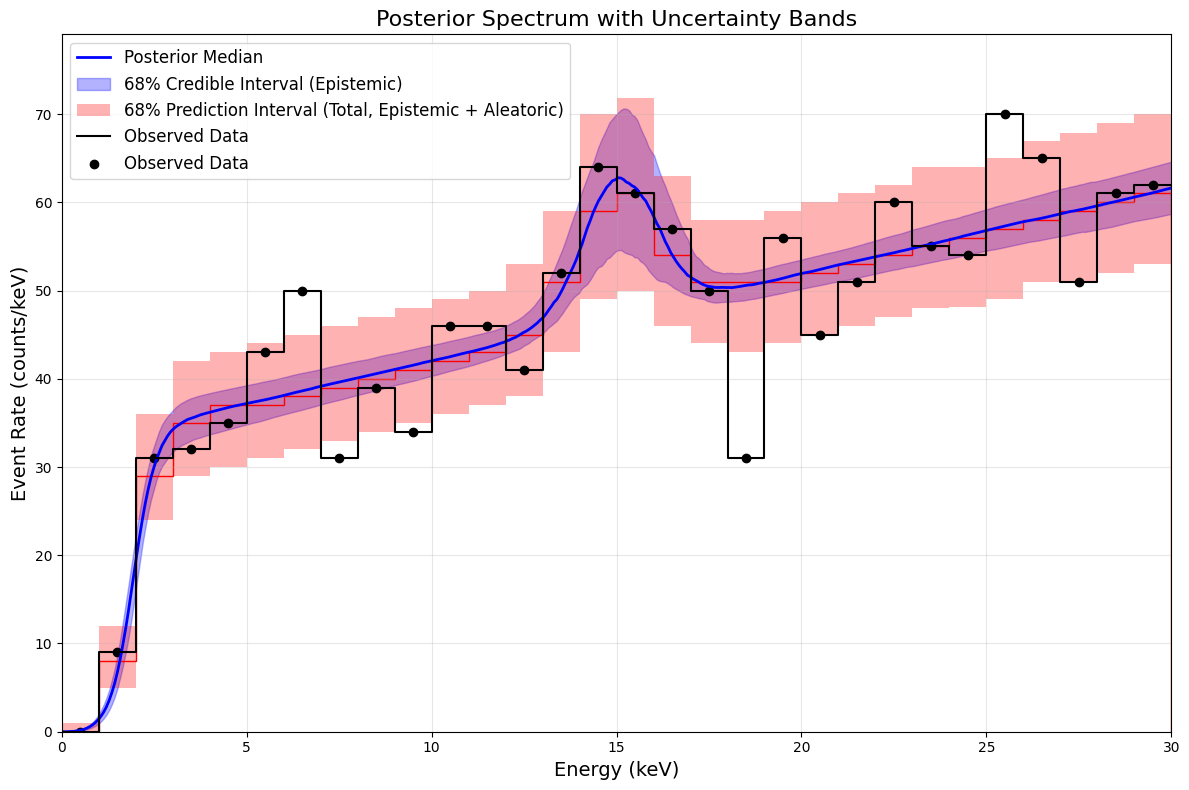

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the median spectrum
ax.plot(plot_energy, median_spectrum, 'b-', lw=2, label='Posterior Median')

# Plot the 95% credible interval (epistemic uncertainty)
ax.fill_between(plot_energy, lower_95_spectrum, upper_95_spectrum,
                color='blue', alpha=0.3, label='68% Credible Interval (Epistemic)')

# Plot the total uncertainty (epistemic + aleatoric)
# ax.fill_between(hist_centers,
#                 total_lower,
#                 total_upper,
#                 color='red', alpha=0.2, label='95% Prediction Interval (Total, Epistemic + Aleatoric)')
ax.stairs(
    total_upper,
    hist_bins,
    baseline=total_lower,
    color='red',
    label='68% Prediction Interval (Total, Epistemic + Aleatoric)',
    fill=True,
    alpha=0.3
    )
ax.stairs(
    median_spectrum_binned,
    hist_bins,
    color='red',
    alpha=1
    )

# Plot the original data as a step plot
# First convert to histogram format for step plotting
hist_rate = hist_values / (bin_widths * exposure)
ax.step(hist_bins, jnp.append(hist_rate, hist_rate[-1]), 'k-', where='post', lw=1.5,
        label='Observed Data')
ax.scatter(hist_centers, hist_rate, color='k', label='Observed Data')

# Add labels and legend
ax.set_xlabel('Energy (keV)', fontsize=14)
ax.set_ylabel('Event Rate (counts/keV)', fontsize=14)
ax.set_title('Posterior Spectrum with Uncertainty Bands', fontsize=16)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(min_energy, max_energy)
ax.set_ylim(0, max(jnp.max(upper_95_spectrum), jnp.max(total_upper))*1.1)

fig.tight_layout()
plt.show()

## Checking the Goodness-of-fit using a posterior p-value

Finally, we want to do a check to ensure that the fit is actually good! What we do is to check the p-value of our observed data compared to the distribution from data, including all uncertainties.

For now, take my word that p-values are a good way to check goodness of fit; your lecture next week by Dr. Amaral will cover p-values in more detail!

In [ ]:
def p_value_from_empirical_bins(observed_data, sorted_simulations):
    index = jnp.searchsorted(sorted_simulations, observed_data)
    raw_p_value = index/len(sorted_simulations)
    p_value = jnp.min(jnp.stack([raw_p_value, 1-raw_p_value]))
    return p_value

In [ ]:
vectorized_p_value = jax.vmap(p_value_from_empirical_bins, in_axes=(-1))

In [ ]:
index_key, key = jax.random.split(key)
random_indices = jax.random.randint(index_key,
                                   (n_samples_to_plot,),
                                   0, len(samples['threshold']))

sorted_simulations = jnp.sort(total_uncertainty_array, axis=0)

posterior_test_statistics = []
n_repetitions = 10
for i in tqdm(random_indices):
    theta = {param: samples[param][i] for param in
             ['threshold', 'rolloff_width', 'bg_rate', 'beta_slope',
              'signal_mean', 'signal_sigma', 'signal_amplitude']}
    rate = get_model_rate(theta, plot_energy)
    spectrum_samples.append(rate)
    for _ in range(n_repetitions):
        # Generate Poisson samples for this rate curve
        poisson_key, key = jax.random.split(key)
        this_loop_samples = sample_from_rate_model(poisson_key, theta, plot_energy)
        this_loop_hist = jnp.histogram(this_loop_samples, bins=hist_bins)[0]

        # Append test statistic generated using Fisher's method
        p_values_this_loop = vectorized_p_value(this_loop_hist[1:], sorted_simulations[:,1:])
        posterior_test_statistics.append(-2*jnp.sum(jnp.log(p_values_this_loop)))

observed_test_statistic = -2*jnp.sum(jnp.log(vectorized_p_value(hist_rate[1:], sorted_simulations[:,1:])))

100%|██████████| 400/400 [01:03<00:00,  6.29it/s]


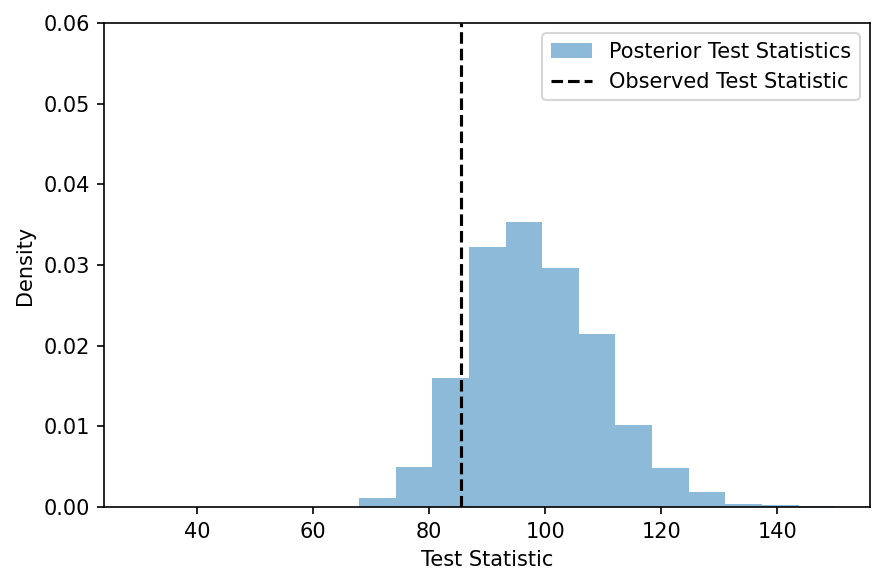

p-value: 0.892.


In [ ]:
p_value = 1 - np.searchsorted(np.sort(posterior_test_statistics), observed_test_statistic)/len(posterior_test_statistics)
# p_value = np.min(np.stack([raw_p_value, 1-raw_p_value]))

ylim=(0,0.06)
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)


ax.hist(posterior_test_statistics, label="Posterior Test Statistics", density=True, alpha=0.5, bins=np.linspace(30,150,20),)
ax.vlines(x=observed_test_statistic, ymin=ylim[0], ymax=ylim[1], color="k", linestyles="--", label="Observed Test Statistic")

ax.set(xlabel="Test Statistic", ylabel="Density", ylim=ylim)
ax.legend()
fig.tight_layout()
plt.show()

print(f"p-value: {p_value:0.3f}.")